In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Libraries loaded ✅


In [3]:
# Data load karo
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')

print("Orders shape:", orders.shape)
print("Items shape:", items.shape)
print("Products shape:", products.shape)
print("Customers shape:", customers.shape)
print("Payments shape:", payments.shape)
print("\nData loaded successfully ✅")

FileNotFoundError: [Errno 2] No such file or directory: '../data/olist_orders_dataset.csv'

In [3]:
# Data load karo
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')

print("Orders shape:", orders.shape)
print("Items shape:", items.shape)
print("Products shape:", products.shape)
print("Customers shape:", customers.shape)
print("Payments shape:", payments.shape)
print("\nData loaded successfully ✅")

FileNotFoundError: [Errno 2] No such file or directory: '../data/olist_orders_dataset.csv'

In [4]:
# Data load karo
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')

print("Orders shape:", orders.shape)
print("Items shape:", items.shape)
print("Products shape:", products.shape)
print("Customers shape:", customers.shape)
print("Payments shape:", payments.shape)
print("\nData loaded successfully ✅")

Orders shape: (99441, 8)
Items shape: (112650, 7)
Products shape: (32951, 9)
Customers shape: (99441, 5)
Payments shape: (103886, 5)

Data loaded successfully ✅


In [5]:
# Date columns fix karo
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Delivered orders hi lo
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Year aur Month column banao
orders_delivered['year'] = orders_delivered['order_purchase_timestamp'].dt.year
orders_delivered['month'] = orders_delivered['order_purchase_timestamp'].dt.month
orders_delivered['year_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

print("Delivered orders:", len(orders_delivered))
print("Data cleaned ✅")

Delivered orders: 96478
Data cleaned ✅


In [6]:
# Sab tables merge karo
df = orders_delivered.merge(items, on='order_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(products, on='product_id', how='left')

# Delivery delay column
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - 
    df['order_estimated_delivery_date']
).dt.days

print("Master table shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMaster table ready ✅")

Master table shape: (115038, 34)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'year', 'month', 'year_month', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'delivery_delay_days']

Master table ready ✅


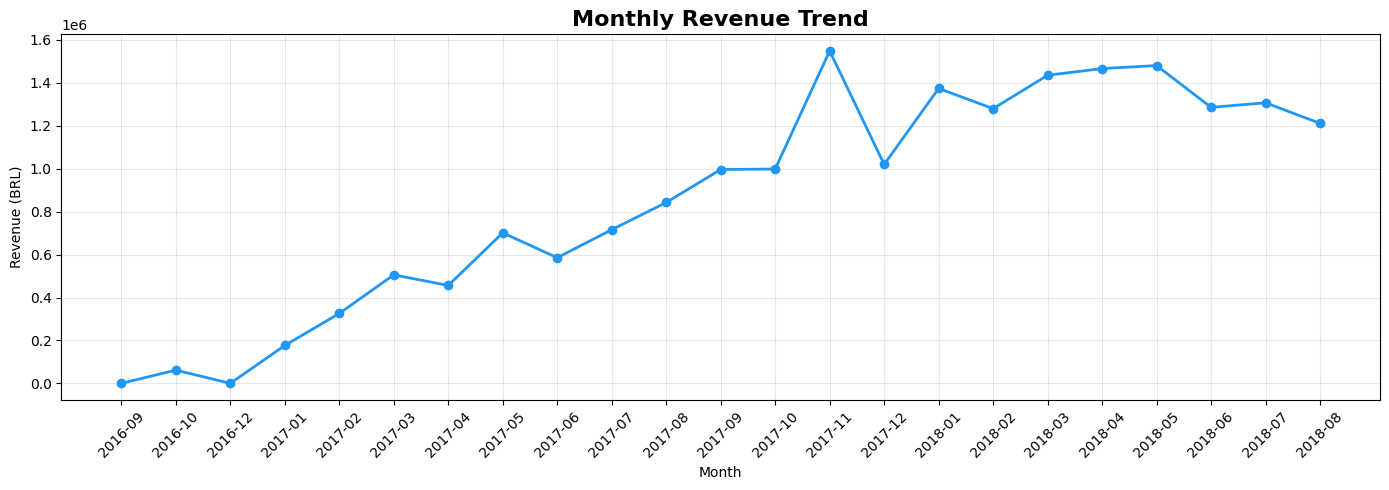

Total Revenue: 19,776,160.44 BRL
Avg Monthly Revenue: 859,833.06 BRL


In [7]:
# Monthly revenue
monthly_revenue = df.groupby('year_month')['payment_value'].sum().reset_index()
monthly_revenue.columns = ['Month', 'Revenue']
monthly_revenue = monthly_revenue.sort_values('Month')

# Plot
plt.figure(figsize=(14,5))
plt.plot(monthly_revenue['Month'].astype(str), 
         monthly_revenue['Revenue'], 
         marker='o', color='#2196F3', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../dashboard/monthly_revenue.png', dpi=150)
plt.show()

print(f"Total Revenue: {df['payment_value'].sum():,.2f} BRL")
print(f"Avg Monthly Revenue: {monthly_revenue['Revenue'].mean():,.2f} BRL")

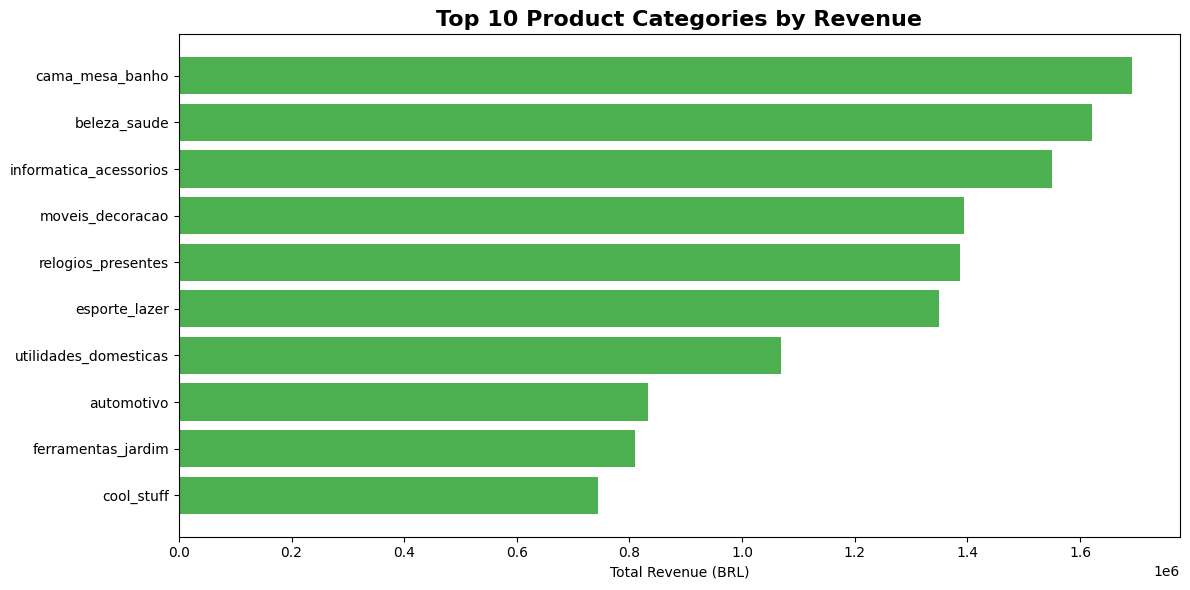

Top 3 Categories:
product_category_name
cama_mesa_banho           1692714.28
beleza_saude              1620684.04
informatica_acessorios    1549372.59
Name: payment_value, dtype: float64


In [8]:
# Top 10 categories by revenue
category_revenue = df.groupby('product_category_name')['payment_value'].sum()
category_revenue = category_revenue.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(category_revenue.index, category_revenue.values, color='#4CAF50')
plt.xlabel('Total Revenue (BRL)')
plt.title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../dashboard/top_categories.png', dpi=150)
plt.show()

print("Top 3 Categories:")
print(category_revenue.head(3))

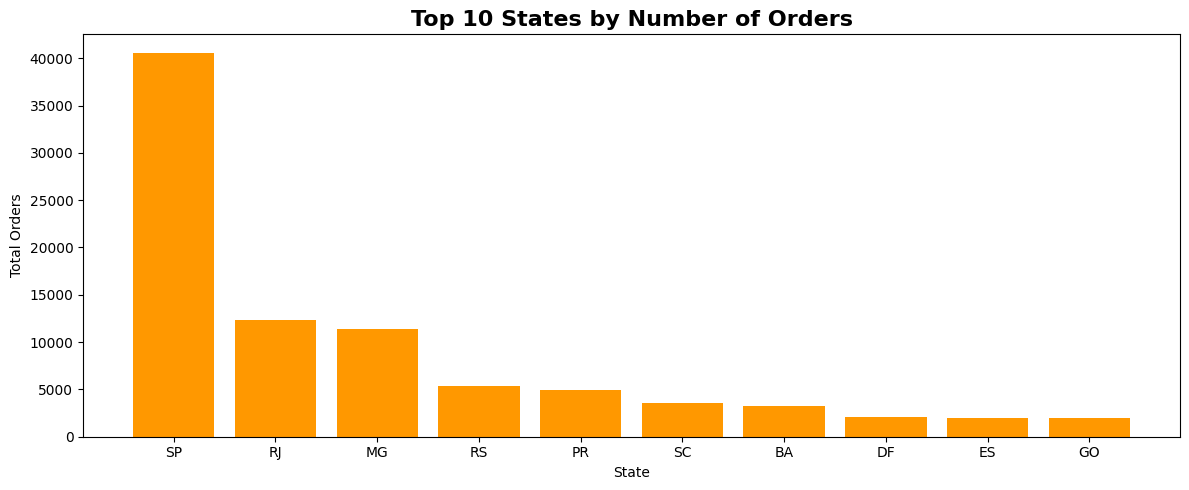

   customer_state  Total_Orders  Total_Revenue  Avg_Order_Value
25             SP         40501     7403993.29       152.590439
18             RJ         12350     2688933.90       180.792974
10             MG         11354     2281229.16       170.025278
22             RS          5345     1110976.47       174.052400
17             PR          4923     1030822.39       175.668437
23             SC          3546      767093.97       181.689713
4              BA          3256      773182.02       196.738427
6              DF          2080      421374.86       174.049922
7              ES          1995      398321.90       172.657954
8              GO          1957      493068.70       207.870447


In [9]:
# Top states by orders
state_orders = df.groupby('customer_state').agg(
    Total_Orders=('order_id', 'nunique'),
    Total_Revenue=('payment_value', 'sum'),
    Avg_Order_Value=('payment_value', 'mean')
).reset_index().sort_values('Total_Orders', ascending=False).head(10)

plt.figure(figsize=(12,5))
plt.bar(state_orders['customer_state'], 
        state_orders['Total_Orders'], 
        color='#FF9800')
plt.title('Top 10 States by Number of Orders', fontsize=16, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Orders')
plt.tight_layout()
plt.savefig('../dashboard/state_orders.png', dpi=150)
plt.show()

print(state_orders)

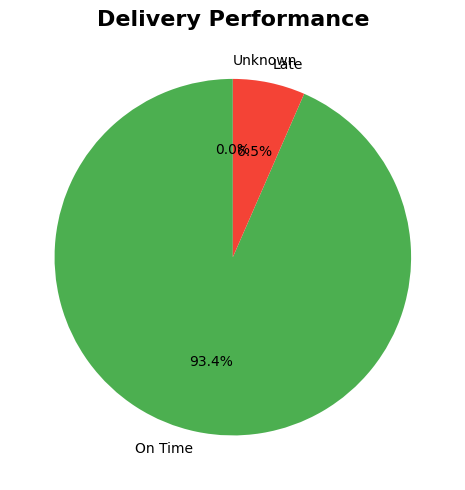

Late Delivery Rate: 6.5%


In [10]:
# Late vs On time delivery
df['delivery_status'] = df['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'On Time' if pd.notnull(x) else 'Unknown'
)

status_counts = df['delivery_status'].value_counts()

plt.figure(figsize=(8,5))
plt.pie(status_counts, 
        labels=status_counts.index, 
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336', '#9E9E9E'],
        startangle=90)
plt.title('Delivery Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/delivery_performance.png', dpi=150)
plt.show()

late_pct = (status_counts.get('Late', 0) / status_counts.sum()) * 100
print(f"Late Delivery Rate: {late_pct:.1f}%")

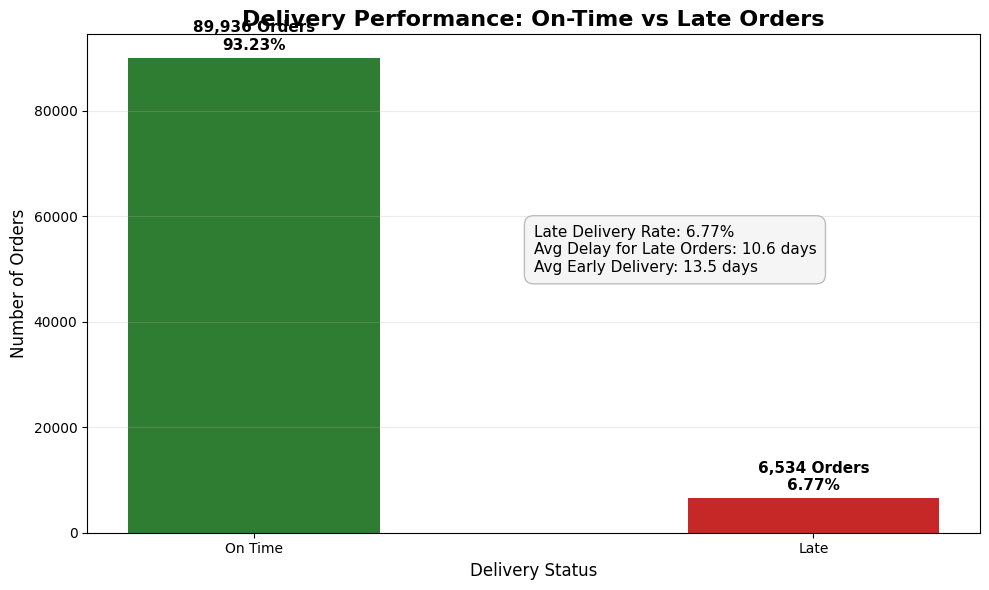

Delivery Performance Summary:
  Delivery Status  Orders  Percentage
0         On Time   89936       93.23
1            Late    6534        6.77

Late Delivery Rate: 6.77%
Average delay among late orders: 10.6 days
Average early delivery days: 13.5 days


In [11]:
import os

# dashboard folder ensure karo
os.makedirs('../dashboard', exist_ok=True)

# Order-level delivery analysis — duplicate rows avoid karne ke liye orders_delivered use kar rahe hain
delivery_df = orders_delivered.copy()

# Delivery delay calculate
delivery_df['delivery_delay_days'] = (
    delivery_df['order_delivered_customer_date'] - 
    delivery_df['order_estimated_delivery_date']
).dt.days

# Only valid delivered orders with delivery date
delivery_df = delivery_df.dropna(subset=['delivery_delay_days'])

# Delivery status
delivery_df['delivery_status'] = np.where(
    delivery_df['delivery_delay_days'] > 0,
    'Late',
    'On Time'
)

# Counts
delivery_summary = delivery_df['delivery_status'].value_counts().reset_index()
delivery_summary.columns = ['Delivery Status', 'Orders']

# Percentage
delivery_summary['Percentage'] = (
    delivery_summary['Orders'] / delivery_summary['Orders'].sum() * 100
).round(2)

# Ensure order
delivery_summary['Delivery Status'] = pd.Categorical(
    delivery_summary['Delivery Status'], 
    categories=['On Time', 'Late'], 
    ordered=True
)
delivery_summary = delivery_summary.sort_values('Delivery Status')

# Metrics for later cells
late_orders = delivery_summary.loc[
    delivery_summary['Delivery Status'] == 'Late', 'Orders'
].sum()

total_delivery_orders = delivery_summary['Orders'].sum()
late_pct = (late_orders / total_delivery_orders) * 100

avg_delay_late = delivery_df[delivery_df['delivery_delay_days'] > 0]['delivery_delay_days'].mean()
avg_early_days = abs(delivery_df[delivery_df['delivery_delay_days'] <= 0]['delivery_delay_days'].mean())

# Plot
plt.figure(figsize=(10, 6))

colors = ['#2E7D32', '#C62828']

bars = plt.bar(
    delivery_summary['Delivery Status'].astype(str),
    delivery_summary['Orders'],
    color=colors,
    width=0.45
)

plt.title('Delivery Performance: On-Time vs Late Orders', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.grid(axis='y', alpha=0.25)

# Add labels on bars
for bar, pct in zip(bars, delivery_summary['Percentage']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1000,
        f'{int(height):,} Orders\n{pct}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Add insight box
insight_text = (
    f"Late Delivery Rate: {late_pct:.2f}%\n"
    f"Avg Delay for Late Orders: {avg_delay_late:.1f} days\n"
    f"Avg Early Delivery: {avg_early_days:.1f} days"
)

plt.text(
    0.5, 
    max(delivery_summary['Orders']) * 0.55,
    insight_text,
    fontsize=11,
    bbox=dict(facecolor='#F5F5F5', edgecolor='#BDBDBD', boxstyle='round,pad=0.6')
)

plt.tight_layout()
plt.savefig('../dashboard/delivery_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Delivery Performance Summary:")
print(delivery_summary)

print(f"\nLate Delivery Rate: {late_pct:.2f}%")
print(f"Average delay among late orders: {avg_delay_late:.1f} days")
print(f"Average early delivery days: {avg_early_days:.1f} days")

Delivery records used (valid): 115030
delivery_status
On Time    93.45
Late        6.55
Name: count, dtype: float64


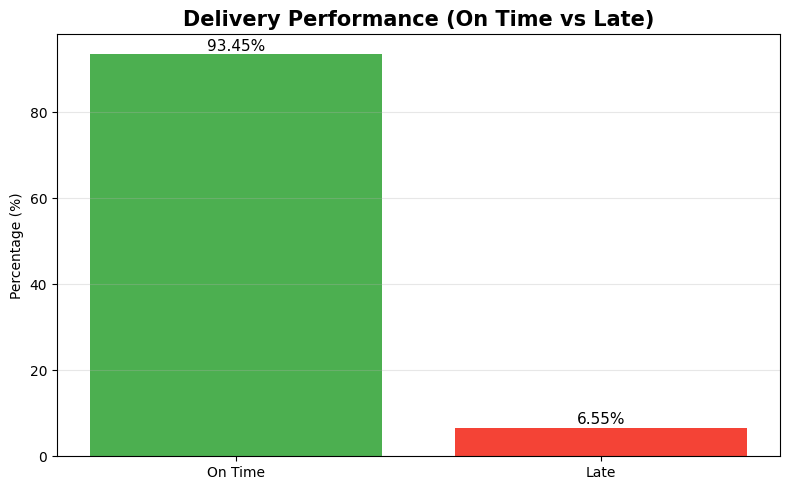

Late Delivery Rate: 6.55%


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Only keep rows where we can actually compare delivery vs estimated
df_valid = df[
    (df['order_estimated_delivery_date'].notna()) &
    (df['order_delivered_customer_date'].notna()) &
    (df['delivery_delay_days'].notna())
].copy()

# 2) Create status
df_valid['delivery_status'] = np.where(df_valid['delivery_delay_days'] <= 0, 'On Time', 'Late')

# 3) Compute rates
status_counts = df_valid['delivery_status'].value_counts()
status_pct = (status_counts / status_counts.sum() * 100).round(2)

print("Delivery records used (valid):", len(df_valid))
print(status_pct)

# 4) Plot: Bar chart (cleaner than pie)
plt.figure(figsize=(8,5))
bars = plt.bar(status_pct.index, status_pct.values, color=['#4CAF50', '#F44336'])

# Add percentage labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f"{yval:.2f}%",
             ha='center', va='bottom', fontsize=11)

plt.title('Delivery Performance (On Time vs Late)', fontsize=15, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../dashboard/delivery_performance.png', dpi=150)
plt.show()

late_rate = status_pct.get('Late', 0)
print(f"Late Delivery Rate: {late_rate:.2f}%")

In [13]:
print("=" * 50)
print("       BUSINESS METRICS SUMMARY")
print("=" * 50)

print(f"\n📦 Total Orders        : {df['order_id'].nunique():,}")
print(f"👥 Total Customers     : {df['customer_id'].nunique():,}")
print(f"💰 Total Revenue       : {df['payment_value'].sum():,.0f} BRL")
print(f"🛒 Avg Order Value     : {df['payment_value'].mean():,.2f} BRL")
print(f"📦 Total Products      : {df['product_id'].nunique():,}")
print(f"🚚 Late Delivery Rate  : {late_pct:.1f}%")
print(f"📅 Date Range          : {df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}")

print("\n" + "=" * 50)
print("Analysis Complete ✅")

       BUSINESS METRICS SUMMARY

📦 Total Orders        : 96,478
👥 Total Customers     : 96,478
💰 Total Revenue       : 19,776,160 BRL
🛒 Avg Order Value     : 171.91 BRL
📦 Total Products      : 32,216
🚚 Late Delivery Rate  : 6.8%
📅 Date Range          : 2016-09-15 to 2018-08-29

Analysis Complete ✅
